In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, 
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# Verileri yükle
X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

print("Veriler yüklendi!")
print("Train:", X_train.shape, "Test:", X_test.shape)

Veriler yüklendi!
Train: (120000, 10) Test: (30000, 10)


In [2]:
# Class imbalance için scale_pos_weight hesapla
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.1f}")

# Modelleri tanımla
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale, n_estimators=100, random_state=42, eval_metric='logloss')
}

# Eğit ve değerlendir
results = {}
for name, model in models.items():
    print(f"\n{name} eğitiliyor...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'AUC': auc, 'F1': f1, 'model': model}
    print(f"  AUC: {auc:.4f} | F1: {f1:.4f}")

print("\n=== SONUÇLAR ===")
for name, r in results.items():
    print(f"{name}: AUC={r['AUC']:.4f}, F1={r['F1']:.4f}")

scale_pos_weight: 14.0

Logistic Regression eğitiliyor...
  AUC: 0.8343 | F1: 0.2930

Random Forest eğitiliyor...
  AUC: 0.8328 | F1: 0.2481

XGBoost eğitiliyor...
  AUC: 0.8499 | F1: 0.3470

=== SONUÇLAR ===
Logistic Regression: AUC=0.8343, F1=0.2930
Random Forest: AUC=0.8328, F1=0.2481
XGBoost: AUC=0.8499, F1=0.3470


Model kaydedildi!

SHAP hesaplanıyor...


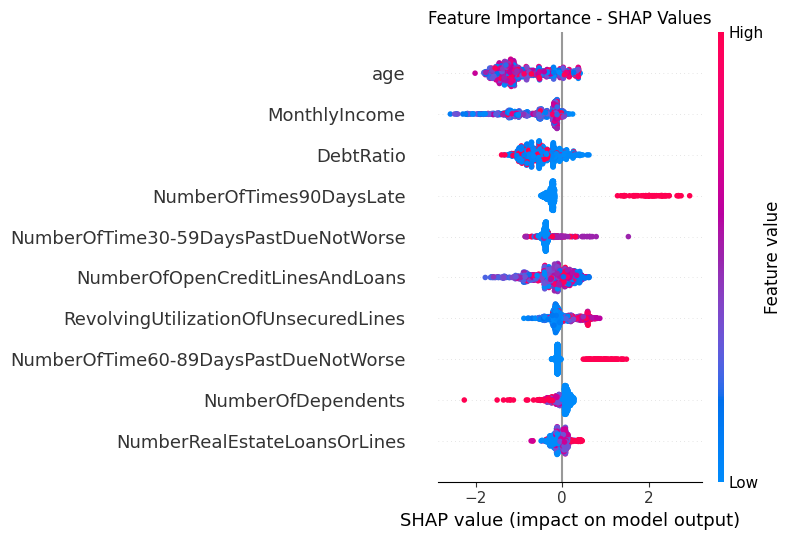

SHAP grafiği kaydedildi!


In [3]:
import shap

# En iyi modeli kaydet
best_model = results['XGBoost']['model']
pickle.dump(best_model, open('../data/model.pkl', 'wb'))
print("Model kaydedildi!")

# SHAP analizi
print("\nSHAP hesaplanıyor...")
explainer = shap.TreeExplainer(best_model)
X_train_raw = pd.read_csv('../data/X_train_raw.csv')
shap_values = explainer.shap_values(X_train_raw[:1000])

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_raw[:1000], show=False)
plt.title('Feature Importance - SHAP Values')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP grafiği kaydedildi!")